## Feature Engineering

Added 3 scenarios at the bottom:
Feature 1: The Snowball Effect (recent_incident_count)
The Insight: Transit delays are rarely isolated; one mechanical failure causes a "ripple effect" of passenger overcrowding elsewhere.

Feature 2: Double Trouble (is_monday_am_peak)
The Insight: Not all weekdays are equal. Monday mornings are the "stress test" for the TTC after the weekend reset.

Feature 3: Station Load Score (station_load_score)
The Insight: Station "busyness" isn't static. A quiet station at 5 PM is safer than a hub at 5 PM.


In [2]:
import numpy as np
import pandas as pd
import datetime
from datetime import datetime, timedelta

# import matplotlib
from matplotlib import pyplot
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import matplotlib.image as mpimg

# import seaborn
import seaborn as sns

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

In [3]:
# to be able to see multiple outputs from single cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

### Import Data

In [4]:
processed_df = pd.read_csv('../../data/processed/final_for_EDA/ttc_cleaned_final_with_peaktimes.csv')
code_description_df = pd.read_csv('../../data/raw/CodeDescriptions.csv')

In [5]:
processed_df.info()
processed_df

code_description_df.info()
code_description_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20316 entries, 0 to 20315
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   year           20316 non-null  int64 
 1   month          20316 non-null  object
 2   date           20316 non-null  object
 3   time           20316 non-null  object
 4   day            20316 non-null  object
 5   station        20316 non-null  object
 6   code           20316 non-null  object
 7   min_delay      20316 non-null  int64 
 8   min_gap        20316 non-null  int64 
 9   bound          20316 non-null  object
 10  line           20316 non-null  object
 11  vehicle        20316 non-null  int64 
 12  time_hms       20316 non-null  object
 13  time_category  20316 non-null  object
 14  day_category   20316 non-null  object
dtypes: int64(4), object(11)
memory usage: 2.3+ MB


,year,month,date,time,day,station,code,min_delay,min_gap,bound,line,vehicle,time_hms,time_category,day_category
0,2025,March,2025-03-16,13:49,Sunday,old mill,PUTIJ,10,14,E,BD,5103,13:49:00,Mid_Day,Weekend
1,2025,January,2025-01-01,2:10,Wednesday,bathurst,MUSAN,5,9,E,BD,5227,02:10:00,Early_AM,Holiday
2,2025,February,2025-02-05,20:38,Wednesday,bathurst,SUDP,5,9,W,BD,5148,20:38:00,Evening,Weekday
3,2025,March,2025-03-21,11:40,Friday,bathurst,MUDD,5,9,W,BD,5170,11:40:00,Mid_Day,Weekday
4,2025,June,2025-06-11,15:32,Wednesday,bathurst,SUO,5,9,E,BD,5035,15:32:00,PM_Peak,Weekday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20311,2021,July,2021-07-02,22:20,Friday,yorkdale,SUDP,5,12,N,YU,5691,22:20:00,Late_Evening,Weekday
20312,2021,July,2021-07-27,18:04,Tuesday,yorkdale,TUO,5,8,S,YU,5431,18:04:00,PM_Peak,Weekday
20313,2021,August,2021-08-08,18:23,Sunday,yorkdale,MUO,5,10,S,YU,5856,18:23:00,PM_Peak,Weekend
20314,2026,January,2026-01-25,17:23,Sunday,yorkdale,PUTIS,5,10,N,YU,6056,17:23:00,PM_Peak,Weekend


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   _id          140 non-null    int64 
 1   CODE         140 non-null    object
 2   DESCRIPTION  140 non-null    object
dtypes: int64(1), object(2)
memory usage: 3.4+ KB


,_id,CODE,DESCRIPTION
0,1,EUAC,AIR CONDITIONING
1,2,EUAL,ALTERNATING CURRENT
2,3,EUATC,ATC RC&S EQUIPMENT
3,4,EUBK,BRAKES
4,5,EUBO,BODY
...,...,...,...
135,136,TUSC,OPERATOR OVERSPEED
136,137,TUSET,CONTROLS IMPROPERLY BLOWN DOWN
137,138,TUST,STORM TRAINS
138,139,TUSUP,SUPERVISORY ERROR


### Review Target Variable

In [6]:
processed_df["code"].value_counts(dropna=True).head(20)

code
SUDP     2739
PUOPO    1460
SUUT     1305
MUIR     1274
SUO      1254
MUI      1032
MUPAA     790
MUSAN     685
MUATC     653
TUO       609
SUAP      537
MUO       453
EUDO      420
SUEAS     402
PUTWZ     396
MUDD      377
TUMVS     272
MUTO      267
EUNT      252
SUG       220
Name: count, dtype: int64

In [7]:
top_codes = processed_df["code"].value_counts().head(20).index
processed_df["code_reduced"] = processed_df["code"].where(
    processed_df["code"].isin(top_codes),
    other="OTHER"
)

### Feature Engineering for Code Prediction

#### Time-Based Features

In [8]:
processed_df["hour"] = pd.to_datetime(processed_df["time_hms"]).dt.hour
processed_df["month_num"] = pd.to_datetime(processed_df["date"]).dt.month

# Cyclical encoding
processed_df["hour_sin"] = np.sin(2*np.pi*processed_df["hour"]/24)
processed_df["hour_cos"] = np.cos(2*np.pi*processed_df["hour"]/24)

#### Location Feature - Frequency Encoding

In [9]:
station_freq = processed_df["station"].value_counts()
processed_df["station_freq"] = processed_df["station"].map(station_freq)

#### Historical Station & Code

To capture how common a code is at a station

In [10]:
station_code_prob = (
    processed_df
    .groupby(["station","code"])
    .size()
    / processed_df.groupby("station").size()
)

processed_df["station_code_likelihood"] = processed_df.set_index(
    ["station","code"]
).index.map(station_code_prob)

#### Delay Severity Category

In [11]:
processed_df["delay_category"] = pd.cut(
    processed_df["min_delay"],
    bins=[0,10,20,50,1000],
    labels=["Low","Medium","High","Extreme"]
)

#### check dataset

In [12]:
processed_df.info()
processed_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20316 entries, 0 to 20315
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   year                     20316 non-null  int64   
 1   month                    20316 non-null  object  
 2   date                     20316 non-null  object  
 3   time                     20316 non-null  object  
 4   day                      20316 non-null  object  
 5   station                  20316 non-null  object  
 6   code                     20316 non-null  object  
 7   min_delay                20316 non-null  int64   
 8   min_gap                  20316 non-null  int64   
 9   bound                    20316 non-null  object  
 10  line                     20316 non-null  object  
 11  vehicle                  20316 non-null  int64   
 12  time_hms                 20316 non-null  object  
 13  time_category            20316 non-null  object  
 14  day_ca

,year,month,date,time,day,station,code,min_delay,min_gap,bound,line,vehicle,time_hms,time_category,day_category,code_reduced,hour,month_num,hour_sin,hour_cos,station_freq,station_code_likelihood,delay_category
0,2025,March,2025-03-16,13:49,Sunday,old mill,PUTIJ,10,14,E,BD,5103,13:49:00,Mid_Day,Weekend,OTHER,13,3,-0.258819,-9.659258e-01,127,0.015748,Low
1,2025,January,2025-01-01,2:10,Wednesday,bathurst,MUSAN,5,9,E,BD,5227,02:10:00,Early_AM,Holiday,MUSAN,2,1,0.500000,8.660254e-01,161,0.037267,Low
2,2025,February,2025-02-05,20:38,Wednesday,bathurst,SUDP,5,9,W,BD,5148,20:38:00,Evening,Weekday,SUDP,20,2,-0.866025,5.000000e-01,161,0.211180,Low
3,2025,March,2025-03-21,11:40,Friday,bathurst,MUDD,5,9,W,BD,5170,11:40:00,Mid_Day,Weekday,MUDD,11,3,0.258819,-9.659258e-01,161,0.080745,Low
4,2025,June,2025-06-11,15:32,Wednesday,bathurst,SUO,5,9,E,BD,5035,15:32:00,PM_Peak,Weekday,SUO,15,6,-0.707107,-7.071068e-01,161,0.105590,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20311,2021,July,2021-07-02,22:20,Friday,yorkdale,SUDP,5,12,N,YU,5691,22:20:00,Late_Evening,Weekday,SUDP,22,7,-0.500000,8.660254e-01,279,0.096774,Low
20312,2021,July,2021-07-27,18:04,Tuesday,yorkdale,TUO,5,8,S,YU,5431,18:04:00,PM_Peak,Weekday,TUO,18,7,-1.000000,-1.836970e-16,279,0.017921,Low
20313,2021,August,2021-08-08,18:23,Sunday,yorkdale,MUO,5,10,S,YU,5856,18:23:00,PM_Peak,Weekend,MUO,18,8,-1.000000,-1.836970e-16,279,0.025090,Low
20314,2026,January,2026-01-25,17:23,Sunday,yorkdale,PUTIS,5,10,N,YU,6056,17:23:00,PM_Peak,Weekend,OTHER,17,1,-0.965926,-2.588190e-01,279,0.007168,Low


#### Selecting:
> * time_category
> * day_category
> * month_num, year
> * hour_sin, hour_cos
> * hour
> * station_freq
> * station_code_likelihood
> * min_gap, min_delay or delay_category
> * bound
> * line

### Target Variable:
> * code_reduced

#### Univariate Statistical Test

For Numerical Features - ANOVA F-Test

In [13]:
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(processed_df["code_reduced"])

numeric_features = [
    "month_num", "year", "hour",
    "hour_sin", "hour_cos",
    "station_freq", "min_gap", "min_delay",
    "station_code_likelihood"
]

X_num = processed_df[numeric_features]

f_values, p_values = f_classif(X_num, y_encoded)

feature_scores = pd.DataFrame({
    "feature": numeric_features,
    "F_score": f_values,
    "p_value": p_values
}).sort_values("F_score", ascending=False)

feature_scores

ModuleNotFoundError: No module named 'sklearn'

For Categorical Features - Chi-Square Test

In [ ]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import OrdinalEncoder

cat_features = [
    "time_category",
    "day_category",
    "delay_category",
    "bound",
    "line"
]

X_cat = processed_df[cat_features].astype(str)

encoder = OrdinalEncoder()
X_cat_encoded = encoder.fit_transform(X_cat)

chi_scores, p_vals = chi2(X_cat_encoded, y_encoded)

chi_df = pd.DataFrame({
    "feature": cat_features,
    "chi_score": chi_scores,
    "p_value": p_vals
}).sort_values("chi_score", ascending=False)

chi_df

,feature,chi_score,p_value
4,line,1638.683723,0.000000e+00
0,time_category,1497.205603,1.583725e-305
2,delay_category,94.632593,1.135676e-11
3,bound,32.585826,3.744228e-02
1,day_category,20.334173,4.372078e-01


#### Feature Engineering with Random Forest

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# Target
y = processed_df["code_reduced"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)


# Feature selection
features = [
    "time_category",
    "day_category",
    "month_num",
    "year",
    "hour_sin",
    "hour_cos",
    "hour",
    "station_freq",
    "station_code_likelihood",
    "min_gap",
    "min_delay",
    "delay_category",
    "bound",
    "line"
]

X = processed_df[features]


# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


# Identify categorical columns
categorical_cols = [
    "time_category",
    "day_category",
    "delay_category",
    "bound",
    "line"
]

numeric_cols = list(set(features) - set(categorical_cols))


# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


# Pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

              precision    recall  f1-score   support

           0       0.09      0.02      0.04        84
           1       0.33      0.08      0.13        50
           2       0.62      0.53      0.57       131
           3       0.32      0.13      0.19        75
           4       0.33      0.32      0.33       207
           5       0.42      0.40      0.41       255
           6       0.37      0.14      0.21        91
           7       0.44      0.51      0.47       158
           8       0.37      0.32      0.34       137
           9       0.48      0.21      0.29        53
          10       0.59      0.94      0.72       984
          11       0.77      0.70      0.73       292
          12       0.73      0.61      0.66        79
          13       0.28      0.15      0.19       108
          14       0.79      0.85      0.82       548
          15       0.37      0.23      0.28        80
          16       1.00      0.50      0.67        44
          17       0.44    

In [ ]:
# Get feature names after encoding
ohe = rf_model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)

all_feature_names = list(encoded_cat_features) + numeric_cols

# Get importances
importances = rf_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
28,station_code_likelihood,0.234670
21,station_freq,0.133427
23,month_num,0.101437
22,min_gap,0.086012
29,year,0.069403
26,min_delay,0.067205
27,hour,0.053207
24,hour_sin,0.053159
25,hour_cos,0.047202
7,day_category_Weekday,0.017365


<Figure size 1000x800 with 0 Axes>

<BarContainer object of 20 artists>

Text(0.5, 0, 'Feature Importance')

Text(0.5, 1.0, 'Top 20 Random Forest Feature Importances')

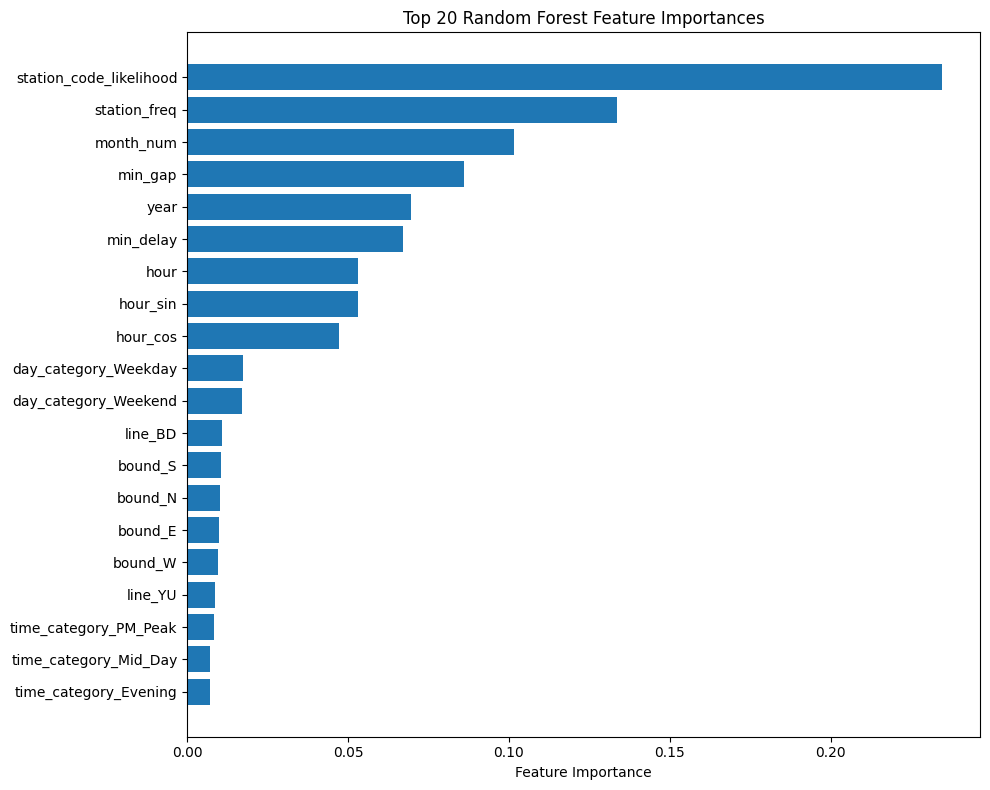

In [ ]:
# Sort and take top 20
top_features = importance_df.sort_values(
    "importance", ascending=True
).tail(20)

plt.figure(figsize=(10, 8))

plt.barh(top_features["feature"], top_features["importance"])

plt.xlabel("Feature Importance")
plt.title("Top 20 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

#### Based on the assessments above, Keep the following features:
> * hour_sin
> * hour
> * year
> * month_num
> * station_freq
> * min_gap
> * line
> * time_category
> * delay_category
> * bound

#where is the station_code_likelihood? 

In [ ]:
processed_df.info()
processed_df

<class 'pandas.DataFrame'>
RangeIndex: 20316 entries, 0 to 20315
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   year                     20316 non-null  int64   
 1   month                    20316 non-null  str     
 2   date                     20316 non-null  str     
 3   time                     20316 non-null  str     
 4   day                      20316 non-null  str     
 5   station                  20316 non-null  str     
 6   code                     20316 non-null  str     
 7   min_delay                20316 non-null  int64   
 8   min_gap                  20316 non-null  int64   
 9   bound                    20316 non-null  str     
 10  line                     20316 non-null  str     
 11  vehicle                  20316 non-null  int64   
 12  time_hms                 20316 non-null  str     
 13  time_category            20316 non-null  str     
 14  day_category     

,year,month,date,time,day,station,code,min_delay,min_gap,bound,line,vehicle,time_hms,time_category,day_category,code_reduced,hour,month_num,hour_sin,hour_cos,station_freq,station_code_likelihood,delay_category
0,2025,March,2025-03-16,13:49,Sunday,old mill,PUTIJ,10,14,E,BD,5103,13:49:00,Mid_Day,Weekend,OTHER,13,3,-0.258819,-9.659258e-01,127,0.015748,Low
1,2025,January,2025-01-01,2:10,Wednesday,bathurst,MUSAN,5,9,E,BD,5227,02:10:00,Early_AM,Holiday,MUSAN,2,1,0.500000,8.660254e-01,161,0.037267,Low
2,2025,February,2025-02-05,20:38,Wednesday,bathurst,SUDP,5,9,W,BD,5148,20:38:00,Evening,Weekday,SUDP,20,2,-0.866025,5.000000e-01,161,0.211180,Low
3,2025,March,2025-03-21,11:40,Friday,bathurst,MUDD,5,9,W,BD,5170,11:40:00,Mid_Day,Weekday,MUDD,11,3,0.258819,-9.659258e-01,161,0.080745,Low
4,2025,June,2025-06-11,15:32,Wednesday,bathurst,SUO,5,9,E,BD,5035,15:32:00,PM_Peak,Weekday,SUO,15,6,-0.707107,-7.071068e-01,161,0.105590,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20311,2021,July,2021-07-02,22:20,Friday,yorkdale,SUDP,5,12,N,YU,5691,22:20:00,Late_Evening,Weekday,SUDP,22,7,-0.500000,8.660254e-01,279,0.096774,Low
20312,2021,July,2021-07-27,18:04,Tuesday,yorkdale,TUO,5,8,S,YU,5431,18:04:00,PM_Peak,Weekday,TUO,18,7,-1.000000,-1.836970e-16,279,0.017921,Low
20313,2021,August,2021-08-08,18:23,Sunday,yorkdale,MUO,5,10,S,YU,5856,18:23:00,PM_Peak,Weekend,MUO,18,8,-1.000000,-1.836970e-16,279,0.025090,Low
20314,2026,January,2026-01-25,17:23,Sunday,yorkdale,PUTIS,5,10,N,YU,6056,17:23:00,PM_Peak,Weekend,OTHER,17,1,-0.965926,-2.588190e-01,279,0.007168,Low


In [ ]:
processed_df.to_csv('../../data/processed/ttc_feature_engineered_final.csv')

In [ ]:
# SNOWBALL EFFECT
# Situation: Subway delays often happen in clusters.
# If there was a delay 20 minutes ago, the system is stressed, making another delay more likely.
# The Feature: recent_incidents (How many delays happened in the last 2 hours?).

# Combine Date and Time into a proper timeline column
# Using .copy() ensures we aren't editing a "view" of the data
processed_df['full_timestamp'] = pd.to_datetime(
    processed_df['date'].astype(str) + ' ' + processed_df['time'].astype(str)
)

# Sort by the timeline so 'past' events are always above 'future' events
processed_df = processed_df.sort_values(by='full_timestamp').reset_index(drop=True)

# Create the Snowball Effect Column
# This looks back exactly 1 hour from the current incident and counts how many others occurred
processed_df['recent_incident_count'] = (
    processed_df.rolling('1H', on='full_timestamp')['code_reduced']
    .count()
    .fillna(0)
)

In [ ]:
# Show the timestamp and the count side-by-side
print(processed_df[['full_timestamp', 'recent_incident_count', 'station_code_likelihood']].tail())

           full_timestamp  recent_incident_count  station_code_likelihood
20311 2026-01-31 16:13:00                    2.0                 0.143312
20312 2026-01-31 19:25:00                    1.0                 0.039711
20313 2026-01-31 20:16:00                    2.0                 0.029412
20314 2026-01-31 22:36:00                    1.0                 0.084615
20315 2026-01-31 23:49:00                    1.0                 0.079787


In [ ]:
# Double Trouble
# Situation: Monday is not a disaster always
# Snowstorm may not be too 
# But Monday on Snowstorm is likely a  disaster.
# The Feature: is_rush_hour_peak (Combining "Monday" + "7 AM – 9 AM").

In [ ]:
# 1. Create the Snowball Effect (History)
processed_df['full_timestamp'] = pd.to_datetime(
    processed_df['date'].astype(str) + ' ' + processed_df['time'].astype(str)
)
processed_df = processed_df.sort_values(by='full_timestamp').reset_index(drop=True)

processed_df['recent_incident_count'] = (
    processed_df.rolling('1H', on='full_timestamp')['code_reduced']
    .count()
    .fillna(0)
)

# 2. Create the "Double Trouble" (Interaction) - THE CORRECTED PART
# We use .dt.dayofweek because your 'day_category' only says 'Weekday'
processed_df['is_monday_am_peak'] = (
    (processed_df['full_timestamp'].dt.dayofweek == 0) & 
    (processed_df['time_category'] == 'AM_Peak')
).astype(int)

# 3. Verify it worked
print(f"Total 'Double Trouble' incidents found: {processed_df['is_monday_am_peak'].sum()}")


Total 'Double Trouble' incidents found: 498


In [ ]:
#  See 'Double Trouble' moments
double_trouble_check = processed_df[processed_df['is_monday_am_peak'] == 1]

# See columns to verify
print(double_trouble_check[['full_timestamp', 'day_category', 'time_category', 'is_monday_am_peak']].head(10))

         full_timestamp day_category time_category  is_monday_am_peak
65  2021-01-25 06:39:00      Weekday       AM_Peak                  1
66  2021-01-25 07:24:00      Weekday       AM_Peak                  1
67  2021-01-25 08:55:00      Weekday       AM_Peak                  1
347 2021-05-10 06:33:00      Weekday       AM_Peak                  1
348 2021-05-10 08:00:00      Weekday       AM_Peak                  1
419 2021-06-07 06:30:00      Weekday       AM_Peak                  1
482 2021-07-05 06:43:00      Weekday       AM_Peak                  1
518 2021-07-26 07:24:00      Weekday       AM_Peak                  1
538 2021-08-02 08:50:00      Weekday       AM_Peak                  1
583 2021-08-30 08:09:00      Weekday       AM_Peak                  1


In [19]:
# When "Busy" is relative
# Situation: 5:00 PM doesn’t feel the same everywhere
# Idea: A station isnt an issue just because it’s 5:00 PM; 
# Its an issue because of Density. Station_load_score measures that density.
# Busy Station + Rush Hour = High Load Score (Danger Zone)
# Quiet Station + Rush Hour = Medium Load Score (Safe)
#Busy Station + 3:00 AM = Low Load Score (Empty)

# 'Weight' of each time of day (how crowded the system is generally)
time_weights = {
    'AM_Peak': 1.0, 
    'PM_Peak': 1.0, 
    'Mid-Day': 0.5, 
    'Evening': 0.4, 
    'Late_Night': 0.1
}

# weights to a new column
processed_df['time_intensity'] = processed_df['time_category'].map(time_weights).fillna(0.2)

# Do Station Load Score (Station Busi-ness x Time Intensity)
# This is the 'Crowding' metric for every single row
processed_df['station_load_score'] = processed_df['station_freq'] * processed_df['time_intensity']


In [ ]:
# Display the top 10 highest load scores
print("--- TOP 10 HIGHEST CROWD PRESSURE MOMENTS ---")
top_pressure = processed_df.sort_values(by='station_load_score', ascending=False)

# Use exact column names from the list
view_cols = ['full_timestamp', 'station', 'time_category', 'station_load_score']
print(top_pressure[view_cols].head(10))

--- TOP 10 HIGHEST CROWD PRESSURE MOMENTS ---
           full_timestamp station time_category  station_load_score
9386  2023-12-13 18:21:00   bloor       PM_Peak               970.0
17734 2025-07-19 18:13:00   bloor       PM_Peak               970.0
2256  2022-05-08 18:44:00   bloor       PM_Peak               970.0
12928 2024-08-09 07:01:00   bloor       AM_Peak               970.0
20217 2026-01-26 18:51:00   bloor       PM_Peak               970.0
189   2021-03-11 17:28:00   bloor       PM_Peak               970.0
17677 2025-07-16 06:08:00   bloor       AM_Peak               970.0
12805 2024-08-01 17:59:00   bloor       PM_Peak               970.0
20155 2026-01-24 15:41:00   bloor       PM_Peak               970.0
79    2021-01-28 17:00:00   bloor       PM_Peak               970.0


In [ ]:
# join the descriptions using 'CODE' as the key
processed_df = processed_df.merge(
    code_description_df[['CODE', 'DESCRIPTION']], 
    left_on='code_reduced',   # key in main data
    right_on='CODE',          # key in the description data
    how='left'
)

# Cleanup
# 
#  drop the extra 'CODE' column
processed_df = processed_df.drop(columns=['CODE'])

# 3. Rename to incident_description
processed_df = processed_df.rename(columns={'DESCRIPTION': 'incident_description'})

# Verify
print(processed_df[['code_reduced', 'incident_description']].head())

  code_reduced            incident_description
0        OTHER                             NaN
1        OTHER                             NaN
2        MUATC                     ATC PROJECT
3        OTHER                             NaN
4         EUNT  EQUIPMENT â NO TROUBLE FOUND


<Axes: ylabel='incident_description'>

Text(0.5, 1.0, 'Top 5 TTC Incident Types (Frequency)')

Text(0.5, 0, 'Total Number of Incidents')

Text(0, 0.5, 'Incident Description')

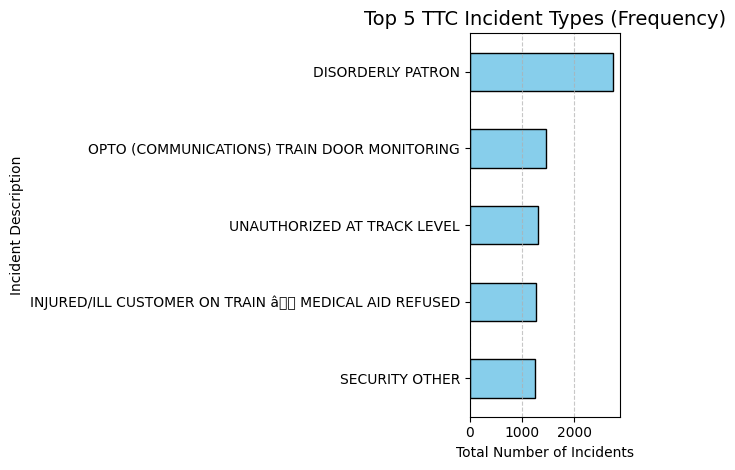

In [20]:
import matplotlib.pyplot as plt

# identify top 5 incident types by frequency
top_5_incidents = processed_df['incident_description'].value_counts().head(5)

# plot
top_5_incidents.plot(kind='barh', color='skyblue', edgecolor='black')

# fix plot
plt.title('Top 5 TTC Incident Types (Frequency)', fontsize=14)
plt.xlabel('Total Number of Incidents')
plt.ylabel('Incident Description')
plt.gca().invert_yaxis() # This puts the #1 incident at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # Prevents the text from getting cut off
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# Target
y = processed_df["code_reduced"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)


# Feature selection
features = [
    "time_category",
    "day_category",
    "month_num",
    "year",
    "hour_sin",
    "hour_cos",
    "hour",
    "station_freq",
    "station_code_likelihood",
    "min_gap",
    "min_delay",
    "delay_category",
    "bound",
    "line",
    'recent_incident_count',
    'is_monday_am_peak',
    'station_load_score'
]

X = processed_df[features]


# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


# Identify categorical columns
categorical_cols = [
    "time_category",
    "day_category",
    "delay_category",
    "bound",
    "line"
]

numeric_cols = list(set(features) - set(categorical_cols))


# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


# Pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

              precision    recall  f1-score   support

           0       0.21      0.06      0.09        84
           1       0.14      0.04      0.06        50
           2       0.62      0.46      0.53       131
           3       0.42      0.13      0.20        75
           4       0.30      0.29      0.30       207
           5       0.39      0.41      0.40       255
           6       0.48      0.11      0.18        91
           7       0.38      0.44      0.41       158
           8       0.44      0.32      0.37       137
           9       0.75      0.17      0.28        53
          10       0.57      0.95      0.71       984
          11       0.74      0.73      0.73       292
          12       0.77      0.61      0.68        79
          13       0.21      0.07      0.11       108
          14       0.81      0.88      0.84       548
          15       0.30      0.16      0.21        80
          16       0.93      0.57      0.70        44
          17       0.43    

In [27]:
# Get feature names after encoding
ohe = rf_model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)

all_feature_names = list(encoded_cat_features) + numeric_cols

# Get importances
importances = rf_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
21,station_code_likelihood,0.203236
27,station_freq,0.100904
28,station_load_score,0.091315
31,month_num,0.082152
23,min_gap,0.074540
26,year,0.058594
32,min_delay,0.058518
30,hour_sin,0.048942
24,hour,0.048441
29,recent_incident_count,0.043749


<Figure size 1000x800 with 0 Axes>

<BarContainer object of 20 artists>

Text(0.5, 0, 'Feature Importance')

Text(0.5, 1.0, 'Top 20 Random Forest Feature Importances')

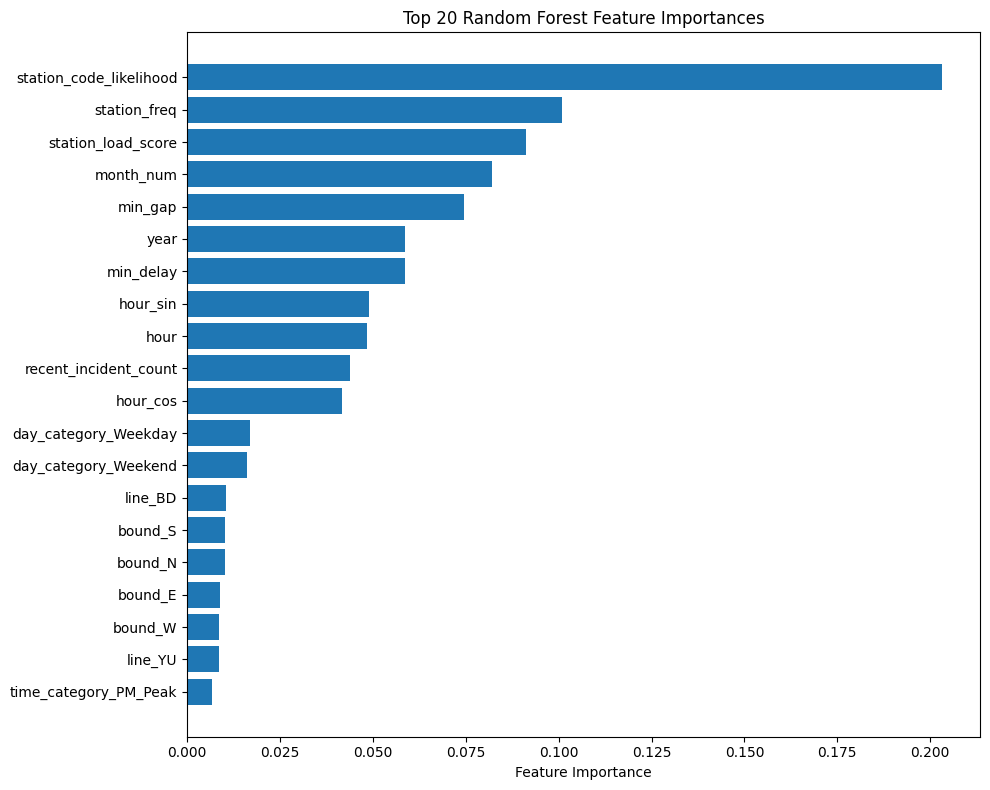

In [28]:
# Sort and show all features
top_features = importance_df.sort_values(
    "importance", ascending=True
).tail(20)

plt.figure(figsize=(10, 8))

plt.barh(top_features["feature"], top_features["importance"])

plt.xlabel("Feature Importance")
plt.title("Top 20 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

In [ ]:
Selected Features 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# Target
y = processed_df["code_reduced"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)


# Feature selection
features = [
    "time_category",
    "day_category",
    "month_num",
    "year",
    "hour_sin",
    "hour_cos",
    "hour",
    "station_freq",
    "station_code_likelihood",
    "min_gap",
    "min_delay",
    "delay_category",
    "bound",
    "line"
]

X = processed_df[features]


# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


# Identify categorical columns
categorical_cols = [
    "time_category",
    "day_category",
    "delay_category",
    "bound",
    "line"
]

numeric_cols = list(set(features) - set(categorical_cols))


# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


# Pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))

#Select only hour_sin, hour, year, month_num, ,station_freq, min_gap, line, time_category, delay_category, bound

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# Target
y = processed_df["code_reduced"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)


# Feature selection
features = [
    "time_category",
    "month_num",
    "year",
    "hour_sin",
    "hour",
    "station_freq",
    "min_gap",
    "delay_category",
    "bound",
    "line"
]

X = processed_df[features]


# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


# Identify categorical columns
categorical_cols = [
    "time_category",
    "delay_category",
    "bound",
    "line"
]

numeric_cols = list(set(features) - set(categorical_cols))


# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


# Pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

              precision    recall  f1-score   support

           0       0.02      0.01      0.02        84
           1       0.06      0.04      0.05        50
           2       0.37      0.31      0.34       131
           3       0.07      0.03      0.04        75
           4       0.10      0.09      0.10       207
           5       0.13      0.12      0.13       255
           6       0.18      0.10      0.13        91
           7       0.18      0.17      0.18       158
           8       0.09      0.06      0.07       137
           9       0.12      0.06      0.08        53
          10       0.35      0.50      0.41       984
          11       0.33      0.40      0.36       292
          12       0.39      0.30      0.34        79
          13       0.08      0.04      0.05       108
          14       0.19      0.24      0.21       548
          15       0.07      0.04      0.05        80
          16       0.48      0.34      0.40        44
          17       0.12    

<Axes: ylabel='feat'>

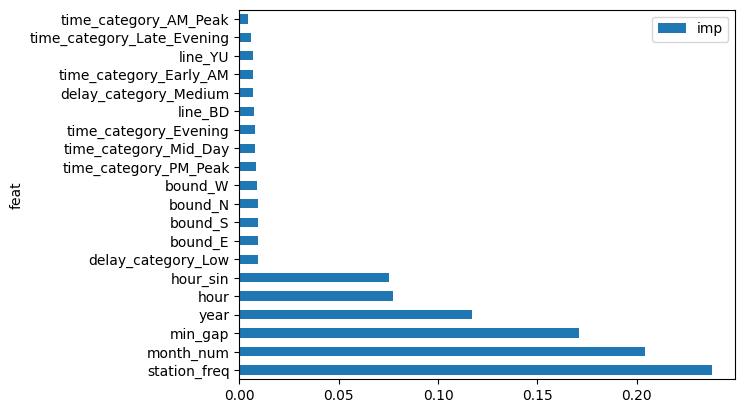

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature names from the pipeline
ohe = rf_model.named_steps['preprocessor'].transformers_[0][1]
cat_features = list(ohe.get_feature_names_out(categorical_cols))
all_features = cat_features + numeric_cols

# Get importances
importances = rf_model.named_steps['classifier'].feature_importances_
feat_df = pd.DataFrame({'feat': all_features, 'imp': importances}).sort_values('imp', ascending=False)

# Plot top 20
feat_df.head(20).plot(kind='barh', x='feat', y='imp')
plt.show()

In [34]:
# !pip install catboost
from catboost import CatBoostClassifier

# 1. Identify which features are categorical (must be strings or integers)
cat_features_indices = [X.columns.get_loc(col) for col in categorical_cols]

# 2. Initialize the model
# 'loss_function' is MultiClass because you have 21 codes
cb_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    random_seed=42,
    verbose=100 # Shows progress every 100 trees
)

# 3. Fit the model
# We tell it exactly which columns are categories
cb_model.fit(
    X_train, y_train,
    cat_features=cat_features_indices,
    eval_set=(X_test, y_test)
)

# 4. Predict and Report
y_pred_cb = cb_model.predict(X_test)
print(classification_report(y_test, y_pred_cb))

0:	learn: 2.9034381	test: 2.9054601	best: 2.9054601 (0)	total: 1.29s	remaining: 10m 43s
100:	learn: 2.2245698	test: 2.3116436	best: 2.3116436 (100)	total: 2m 53s	remaining: 11m 25s
200:	learn: 2.0576641	test: 2.2680139	best: 2.2680139 (200)	total: 6m	remaining: 8m 56s
300:	learn: 1.9504952	test: 2.2603750	best: 2.2594574 (291)	total: 9m 16s	remaining: 6m 8s
400:	learn: 1.8445936	test: 2.2571843	best: 2.2570843 (398)	total: 12m 41s	remaining: 3m 8s
499:	learn: 1.7450794	test: 2.2621180	best: 2.2569365 (401)	total: 16m 21s	remaining: 0us

bestTest = 2.256936545
bestIteration = 401

Shrink model to first 402 iterations.


CatBoostClassifier(depth=6, iterations=500, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=100)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        84
           1       0.00      0.00      0.00        50
           2       0.46      0.25      0.33       131
           3       0.00      0.00      0.00        75
           4       0.20      0.06      0.10       207
           5       0.18      0.10      0.13       255
           6       0.50      0.01      0.02        91
           7       0.28      0.14      0.18       158
           8       0.19      0.02      0.04       137
           9       0.00      0.00      0.00        53
          10       0.33      0.71      0.45       984
          11       0.31      0.51      0.39       292
          12       0.45      0.28      0.34        79
          13       0.00      0.00      0.00       108
          14       0.21      0.31      0.25       548
          15       0.33      0.03      0.05        80
          16       0.57      0.30      0.39        44
          17       0.17    

In [33]:
import sys
!{sys.executable} -m pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.1/100.2 MB 1.3 MB/s eta 0:01:16
   ---------------------------------------- 0.1/100.2 MB 1.2 MB/s eta 0:01:22
   ---------------------------------------- 0.2/100.2 MB 1.3 MB/s eta 0:01:16
   ---------------------------------------- 0.2/100.2 MB 1.3 MB/s eta 0:01:20
   ---------------------------------------- 0.3/100.2 MB 1.2 MB/s eta 0:01:25
   ---------------------------------------- 0.4/100.2 MB 1.2 MB/s eta 0:01:21
   ---------------------------------------- 0.4/100.2 MB 1.2 MB/s eta 0:01:22
   ---------------------------------------- 0.5/100.2 MB 1.2 MB/s eta 0:01:22
   ---------------------------------------- 0.5/100.2 MB 1.2 MB/s eta 0:01:24
   ---------------------------------------- 0.6/100.2 MB 1.2 MB/s eta 0:01:22
   ---------------------------------------- 0.6/100.2 MB 1.2 MB/s eta 0:01:23



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
%pip install scikit-learn

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------------------------- ------------ 41.0/61.0 kB 991.0 kB/s eta 0:00:01
     ---------------------------------------- 61.0/61.0 kB 1.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
    --------------------------------------- 0.2/8.1 MB 3.7 MB/s eta 0:00:03
   -- ------------------------------------- 0.5/8.1 MB 5.0 MB/s eta 0:00:02
   ----- ---------------------------------- 1.1/8.1 MB 6.7 MB/s eta 0:00:02
   ------ --------------------------------- 1.2/8.1 MB 6.6 MB/s eta 0:00:02
   ----------- ---------------------------- 2.3/8.1 MB 9.9 MB/s eta 0:00:01
   --------------- ------------------------ 3.1/8.1 MB 10.9 MB/s eta 0:00:01
   --------------------- ------------------ 4.4/8.1 MB 12.9 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 14.1 MB/s eta 0:00:01
   ---------------------------------- ----- 6.9/8.1 MB 15.7 MB/s eta 0:00:01
   --------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
